# 02 - Is the filter's uncertainty honest?

The narrative version of section 2 of [`../docs/verification-report.md`](../docs/verification-report.md).

A Kalman filter emits two things: an estimate and a variance. Almost all attention goes to
the first. This notebook is about verifying the second, which is the part that decides
whether anything downstream can safely act on the output.

## The model

$$x_k = A x_{k-1} + w_k, \qquad w_k \sim \mathcal{N}(0, Q)$$
$$y_k = C x_k + v_k, \qquad v_k \sim \mathcal{N}(0, R)$$

With $A = C = 1$ this is a random walk observed in noise. $Q$ is how fast the truth may
move; $R$ is how noisy the sensor is. Their **ratio** sets the filter's character.

## Four diagnostics, and why four

| Diagnostic | Needs truth? | Averaged over | Catches |
|---|---|---|---|
| self-simulation RMSE | yes | - | the filter does not track |
| **NEES** | **yes** | **runs** | the variance is wrong although the estimate is fine |
| **NIS** | no | time | same, computable without truth |
| Ljung-Box on innovations | no | time | model mis-specification: structure left in the residual |
| coverage | yes | runs | the credible interval does not contain the truth as often as claimed |

A filter can pass the first and fail every other one. That is the case this notebook builds.

In [1]:
import sys

sys.path[:0] = ["../src", "../tests", "."]

import matplotlib.pyplot as plt
import numpy as np
from style import BAND, ESTIMATE, INK_SECONDARY, OBSERVED, TRUTH, use_report_style

from eeg_state_estimator.statespace import RandomWalkModel, filter_series
from eeg_state_estimator.statespace.diagnostics import (
    chi_square_consistency_bounds,
    credible_interval_coverage,
    ljung_box,
    nees_across_runs,
    nis_over_time,
)

use_report_style()
Q_TRUE, R_TRUE = 0.05, 1.0


def simulate(n_runs, n_samples, seed, q=Q_TRUE):
    rng = np.random.default_rng(seed)
    truth = np.cumsum(rng.normal(0.0, np.sqrt(q), (n_runs, n_samples)), axis=1)
    return truth, truth + rng.normal(0.0, np.sqrt(R_TRUE), (n_runs, n_samples))


def run_bank(model, observed):
    mean = np.empty_like(observed)
    var = np.empty_like(observed)
    for i, row in enumerate(observed):
        t = filter_series(row, model)
        mean[i] = t.mean
        var[i] = t.variance
    return mean, var


print("ready")

ready


## Step 1 - tracking, and a variance that ignores the data

### What we expect

Start the filter at $\hat{x}_0 = 8$ when the truth is near 0. It should converge. The
posterior variance should settle somewhere.

**Prediction to write down:** how many steps to converge, and does the variance curve depend
on which noise realisation we drew?

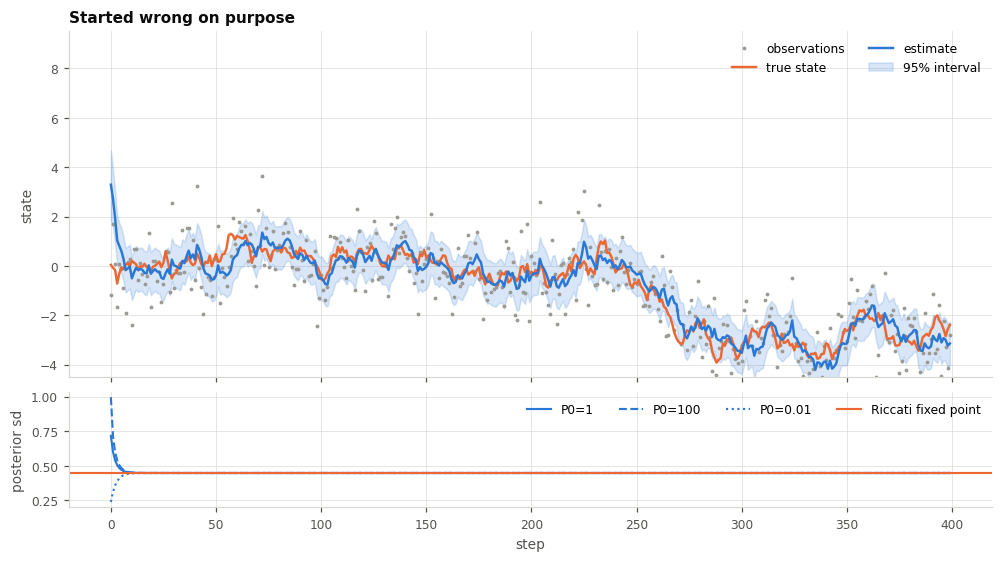

steady-state posterior sd : 0.447214
closed-form Riccati value : 0.447214


In [2]:
truth, observed = simulate(1, 400, seed=2)
model = RandomWalkModel(Q_TRUE, R_TRUE)
track = filter_series(observed[0], model, initial_mean=8.0, initial_variance=1.0)
lo, hi = track.credible_interval(0.95)
k = np.arange(400)

fig, ax = plt.subplots(
    2, 1, figsize=(9, 5), sharex=True, height_ratios=[3, 1], constrained_layout=True
)
ax[0].plot(k, observed[0], ".", color=OBSERVED, ms=3, label="observations")
ax[0].plot(k, truth[0], color=TRUTH, lw=1.6, label="true state")
ax[0].plot(k, track.mean, color=ESTIMATE, lw=1.6, label="estimate")
ax[0].fill_between(k, lo, hi, color=BAND, alpha=0.18, label="95% interval")
ax[0].set_ylim(-4.5, 9.5)
ax[0].legend(ncol=2)
ax[0].set_ylabel("state")
ax[0].set_title("Started wrong on purpose", loc="left")

for p0, style in ((1.0, "-"), (100.0, "--"), (0.01, ":")):
    t2 = filter_series(observed[0], model, initial_mean=8.0, initial_variance=p0)
    ax[1].plot(k, np.sqrt(t2.variance), style, color=ESTIMATE, lw=1.4, label=f"P0={p0:g}")
ax[1].axhline(
    np.sqrt(model.steady_state_posterior_variance()),
    color=TRUTH,
    lw=1.4,
    label="Riccati fixed point",
)
ax[1].set_xlabel("step")
ax[1].set_ylabel("posterior sd")
ax[1].legend(ncol=4)
plt.show()

print(f"steady-state posterior sd : {np.sqrt(track.variance[-1]):.6f}")
print(f"closed-form Riccati value : {np.sqrt(model.steady_state_posterior_variance()):.6f}")

### Analysis

Convergence takes roughly 25 steps, and all three initial variances land on the same curve.

The second panel is the one worth dwelling on: **it was computed without reference to a
single observation.** The variance recursion involves only $A, Q, C, R$. So a filter's
entire uncertainty schedule is knowable before any data is collected, and its limit solves

$$p^2 - Qp - QR = 0, \qquad P_\infty = \frac{pR}{p+R}$$

in closed form. That fact is what the streaming warm-up flag is built on in notebook 03:
"has the filter converged" is answerable from the model alone.

## Step 2 - breaking the filter

### What we expect

Give the filter the wrong $Q$ or $R$ and it should get worse. **Prediction: RMSE will show
it.** That is the metric everyone reaches for, so let us see how much it moves.

In [3]:
truth, observed = simulate(400, 320, seed=0)
AT = 300
lo_b, hi_b = chi_square_consistency_bounds(400)

cases = [
    ("correct", RandomWalkModel(Q_TRUE, R_TRUE)),
    ("Q 10x small", RandomWalkModel(Q_TRUE * 0.1, R_TRUE)),
    ("Q 10x large", RandomWalkModel(Q_TRUE * 10, R_TRUE)),
    ("R 10x large", RandomWalkModel(Q_TRUE, R_TRUE * 10)),
]

print(f"NEES acceptance band at 400 runs: [{lo_b:.3f}, {hi_b:.3f}]")
print()
print(f"{'filter':14} {'RMSE':>7} {'NEES':>8} {'coverage':>9}   verdict")
results = {}
for name, m in cases:
    mean, var = run_bank(m, observed)
    rmse = float(np.sqrt(np.mean((truth[:, AT] - mean[:, AT]) ** 2)))
    nees = nees_across_runs(truth, mean, var, time_index=AT)
    cov = credible_interval_coverage(truth, mean, var, time_index=AT)
    results[name] = (rmse, nees.statistic, cov.fraction)
    v = (
        "consistent"
        if nees.is_consistent
        else ("OVERconfident" if nees.statistic > hi_b else "UNDERconfident")
    )
    print(f"{name:14} {rmse:7.3f} {nees.statistic:8.3f} {cov.fraction:9.2f}   {v}")

base = results["correct"][0]
worst = max(r[0] for r in results.values())
print()
print(f"RMSE spread: {base:.3f} -> {worst:.3f}  ({worst / base - 1:.0%} worse)")
print(
    f"NEES spread: {min(r[1] for r in results.values()):.2f} -> "
    f"{max(r[1] for r in results.values()):.2f}  "
    f"({max(r[1] for r in results.values()) / min(r[1] for r in results.values()):.0f}x)"
)

NEES acceptance band at 400 runs: [0.866, 1.143]

filter            RMSE     NEES  coverage   verdict


correct          0.465    1.082      0.94   consistent


Q 10x small      0.625    5.727      0.60   OVERconfident


Q 10x large      0.616    0.760      0.98   UNDERconfident


R 10x large      0.625    0.573      0.99   UNDERconfident

RMSE spread: 0.465 -> 0.625  (34% worse)
NEES spread: 0.57 -> 5.73  (10x)


### Analysis - the expectation was badly wrong

RMSE moves about **34%**. On a noisy plot that is invisible. NEES moves by a factor of **5**.

The `Q 10x small` row is the dangerous one, and it is worth being able to describe
precisely. Too small a $Q$ tells the filter the state can barely move, so it under-weights
each new observation and its posterior variance collapses to a confidence it has not earned.
**The trajectory still looks fine. The error bars are a lie.**

Coverage confirms it by a completely independent route: the truth falls inside the nominal
95% interval only 60% of the time.

Note the two over-smoothed filters fail the other way, with coverage of 98-99%. That is not
"better than 95%" - it means the intervals are too wide to support a decision.

## Step 3 - the aggregation trap

Now the subtle one, and the one most likely to be got wrong in practice.

NEES is computed per sample. To test it we average and compare against a chi-square bound.
We have 400 independent runs of 320 samples each, so there are two ways to average.

### What we expect

**Prediction:** averaging each run over its own 320 time points gives a larger sample than
averaging 400 runs at one instant, so it should be the *better* test. A correct filter
should pass about 95% of the time either way.

In [4]:
truth, observed = simulate(400, 520, seed=1)
BURN = 200
model = RandomWalkModel(Q_TRUE, R_TRUE)

mean = np.empty_like(observed)
var = np.empty_like(observed)
nu = np.empty_like(observed)
S = np.empty_like(observed)
for i, row in enumerate(observed):
    t = filter_series(row, model)
    mean[i], var[i], nu[i], S[i] = t.mean, t.variance, t.innovation, t.innovation_variance

err = (truth - mean)[:, BURN:]
nees_time = (err**2 / var[:, BURN:]).mean(axis=1)
nis_time = (nu**2 / S)[:, BURN:].mean(axis=1)
lo_t, hi_t = chi_square_consistency_bounds(err.shape[1])

print(f"Testing each of 400 runs by averaging over its own {err.shape[1]} time points.")
print(f"chi-square bounds: [{lo_t:.3f}, {hi_t:.3f}]   a correct filter should pass ~95%")
print()
print(f"  NEES over time : {np.mean((nees_time >= lo_t) & (nees_time <= hi_t)):6.1%} pass")
print(f"  NIS  over time : {np.mean((nis_time >= lo_t) & (nis_time <= hi_t)):6.1%} pass")
print()
n_at = nees_across_runs(truth, mean, var, time_index=400)
print(
    f"  NEES across runs at one instant : {n_at.statistic:.3f} in "
    f"[{n_at.lower:.3f}, {n_at.upper:.3f}] -> {'PASS' if n_at.is_consistent else 'FAIL'}"
)

Testing each of 400 runs by averaging over its own 320 time points.
chi-square bounds: [0.851, 1.161]   a correct filter should pass ~95%

  NEES over time :  66.0% pass
  NIS  over time :  94.5% pass

  NEES across runs at one instant : 1.038 in [0.866, 1.143] -> PASS


### Analysis - the expectation failed, and this one bites in production

Both filters here are **correct**. Yet the time-averaged NEES test rejects a third of them.

A test that fails 34% of the time on correct input is worse than no test: it will pass on
the seed it was developed with, then fail intermittently in CI, and the natural response -
loosening the bound - destroys its power to detect the real faults from Step 2.

Why the two differ:

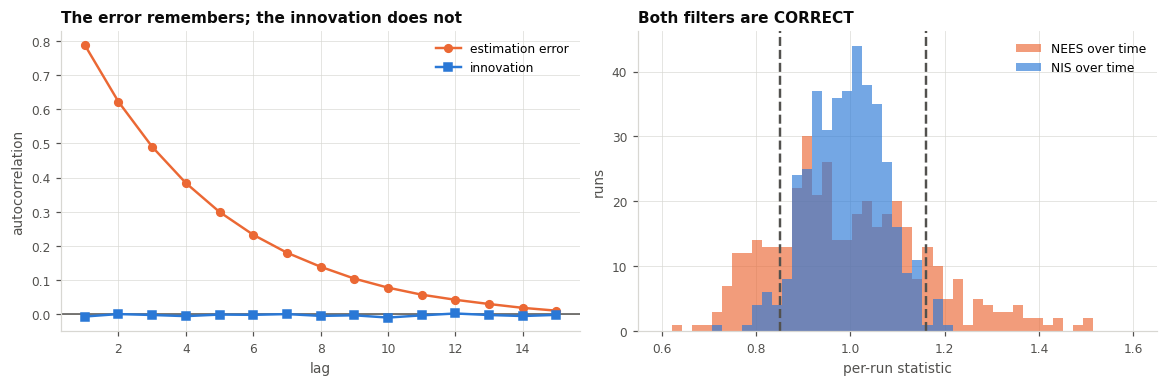

error lag-1 autocorrelation      : +0.788
innovation lag-1 autocorrelation : -0.007


In [5]:
lags = np.arange(1, 16)
err_acf = [np.mean([np.corrcoef(e[:-k], e[k:])[0, 1] for e in err]) for k in lags]
nu_n = (nu / np.sqrt(S))[:, BURN:]
nu_acf = [np.mean([np.corrcoef(v[:-k], v[k:])[0, 1] for v in nu_n]) for k in lags]

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4), constrained_layout=True)
ax[0].axhline(0, color=INK_SECONDARY, lw=1)
ax[0].plot(lags, err_acf, "o-", color=TRUTH, ms=5, label="estimation error")
ax[0].plot(lags, nu_acf, "s-", color=ESTIMATE, ms=5, label="innovation")
ax[0].set_xlabel("lag")
ax[0].set_ylabel("autocorrelation")
ax[0].legend()
ax[0].set_title("The error remembers; the innovation does not", loc="left")

bins = np.linspace(0.6, 1.6, 48)
ax[1].hist(nees_time, bins=bins, color=TRUTH, alpha=0.65, label="NEES over time")
ax[1].hist(nis_time, bins=bins, color=ESTIMATE, alpha=0.65, label="NIS over time")
ax[1].axvline(lo_t, color=INK_SECONDARY, ls="--")
ax[1].axvline(hi_t, color=INK_SECONDARY, ls="--")
ax[1].set_xlabel("per-run statistic")
ax[1].set_ylabel("runs")
ax[1].legend()
ax[1].set_title("Both filters are CORRECT", loc="left")
plt.show()

print(f"error lag-1 autocorrelation      : {err_acf[0]:+.3f}")
print(f"innovation lag-1 autocorrelation : {nu_acf[0]:+.3f}")

### Why

The **innovation** $\nu_k = y_k - C\hat{x}^-_k$ is the genuinely new information in
observation $k$. An optimal filter has already extracted everything predictable from the
past, so what remains is unpredictable - **white by construction**. That is close to a
definition of optimality.

The **error** $x_k - \hat{x}_k$ persists. If the filter sits below the truth at step $k$,
the predict step carries that bias straight into $k+1$. Lag-1 autocorrelation 0.79.

So the chi-square bound, which assumes 320 independent samples, is far too tight for NEES:
the effective sample size is a fraction of that.

**The rule:** NEES across runs, NIS over time. And because NEES needs the true state it is
simulation-only, while NIS - built from $\nu$ and $S$, both of which the filter already
computes - is the one that works on a real recording.

The API enforces this rather than documenting it: `nees_across_runs` takes 2-D
`(n_runs, n_samples)` arrays and a required keyword-only `time_index`, so a time average is
not expressible.

In [6]:
# The signature refuses the mistake rather than warning about it.
try:
    nees_across_runs(err[0], err[0], var[0, BURN:], time_index=10)
except ValueError as exc:
    print("ValueError:", str(exc).split(".")[0])

ValueError: truth must be two-dimensional (n_runs, n_samples), got shape (320,)


## Step 4 - negative controls

Every diagnostic so far has been shown to accept a correct filter. That is only half the
evidence. **A diagnostic that never rejects anything is indistinguishable from
`assert True`**, so each one is also pointed at a knowably broken filter.

In [7]:
_, obs1 = simulate(1, 4000, seed=10)

print(f"{'filter':20} {'Ljung-Box p':>12} {'rejects?':>9}")
for name, m in [
    ("correct", RandomWalkModel(Q_TRUE, R_TRUE)),
    ("Q 10x small", RandomWalkModel(Q_TRUE * 0.1, R_TRUE)),
    ("Q 10x large", RandomWalkModel(Q_TRUE * 10, R_TRUE)),
]:
    t = filter_series(obs1[0], m, initial_variance=m.steady_state_posterior_variance())
    r = ljung_box(t.normalized_innovation[200:], n_lags=20)
    print(f"{name:20} {r.p_value:12.2e} {r.rejects_whiteness()!s:>9}")

print()
t = filter_series(obs1[0], RandomWalkModel(Q_TRUE, R_TRUE * 10))
r = nis_over_time(t.innovation, t.innovation_variance, burn_in=200)
print(
    f"R 10x large -> NIS {r.statistic:.3f}, bounds [{r.lower:.3f}, {r.upper:.3f}], "
    f"consistent={r.is_consistent}"
)

filter                Ljung-Box p  rejects?
correct                  6.03e-01     False
Q 10x small             6.28e-241      True
Q 10x large              9.22e-46      True

R 10x large -> NIS 0.131, bounds [0.956, 1.045], consistent=False


### Analysis

Ljung-Box rejects both mis-specified process variances with p-values beneath machine
noise, and accepts the correct one. NIS catches the mis-scaled observation variance.

Note the correct filter is run with $P_0$ set to the steady-state value. With a diffuse
prior the first few normalised innovations are not unit-variance and the test would reject
for a true reason but the wrong requirement - so either set $P_0$ to steady state or pass a
burn-in, and say which.

## What this establishes

**Demonstrated here**

- The posterior variance recursion never touches the data, so the uncertainty schedule is
  knowable in advance and converges to a closed-form Riccati fixed point from any $P_0$.
- RMSE is nearly blind to a mis-specified filter (34%) where NEES is not (5x). An estimator
  can track well and report uncertainty that is simply wrong.
- Coverage detects the same fault independently, and over-wide intervals are a failure too.
- A time-averaged NEES test rejects ~34% of **correct** filters, because the estimation
  error is autocorrelated (lag-1 0.79) while the innovation is white by construction
  (lag-1 -0.01). NEES across runs; NIS over time.
- NEES needs truth and is simulation-only; NIS is its real-data analogue.
- Every diagnostic rejects a knowably broken filter, not just accepts a correct one.

**Not established here**

- Vector state. Everything is scalar; the diagnostics are written so the scalar case reads
  as $d = 1$ of the general rule, but the vector filter is not implemented.
- Parameter identification. $Q$ and $R$ were given throughout. Estimating them from data by
  maximum likelihood or EM is a separate problem and is not attempted.
- Anything non-Gaussian. A Bernoulli or point-process observation model would need a
  different filter, and most of these diagnostics would need replacing with
  calibration-based checks.

**Next:** [`03_streaming_behaviour.ipynb`](03_streaming_behaviour.ipynb) - running the whole
thing on a sample at a time, and the one filter you are not allowed to use.